# Spark RAPIDS get_json_object acceleration



<a target="_blank" href="https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/10min_to_cudf_colab.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



Before getting started - be sure to change your runtime to use a GPU Hardware accelerator! Use the Runtime -> "Change runtime type" menu option to add a GPU.

# Let's get started using the RAPIDS Accelerator for Apache Spark

In [1]:
!nvidia-smi

Sun Mar 30 00:01:09 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.124.03             Driver Version: 572.60         CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4080 ...    On  |   00000000:01:00.0  On |                  N/A |
|  0%   40C    P8              8W /  320W |    1261MiB /  16376MiB |      7%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!cat /proc/cpuinfo

processor	: 0
vendor_id	: AuthenticAMD
cpu family	: 25
model		: 97
model name	: AMD Ryzen 7 7800X3D 8-Core Processor
stepping	: 2
microcode	: 0xffffffff
cpu MHz		: 4199.901
cache size	: 1024 KB
physical id	: 0
siblings	: 16
core id		: 0
cpu cores	: 8
apicid		: 0
initial apicid	: 0
fpu		: yes
fpu_exception	: yes
cpuid level	: 13
wp		: yes
flags		: fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pge mca cmov pat pse36 clflush mmx fxsr sse sse2 ht syscall nx mmxext fxsr_opt pdpe1gb rdtscp lm constant_tsc rep_good nopl tsc_reliable nonstop_tsc cpuid extd_apicid pni pclmulqdq ssse3 fma cx16 sse4_1 sse4_2 movbe popcnt aes xsave avx f16c rdrand hypervisor lahf_lm cmp_legacy svm cr8_legacy abm sse4a misalignsse 3dnowprefetch osvw topoext perfctr_core ssbd ibrs ibpb stibp vmmcall fsgsbase bmi1 avx2 smep bmi2 erms invpcid avx512f avx512dq rdseed adx smap avx512ifma clflushopt clwb avx512cd sha_ni avx512bw avx512vl xsaveopt xsavec xgetbv1 xsaves avx512_bf16 clzero xsaveerptr arat npt nrip_save t

In [3]:
spark_version='3.5.0'
rapids_version='24.12.0'

In [4]:
%pip install --quiet pyspark=={spark_version}

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pyspark-stubs 3.0.0.post3 requires pyspark<3.1.0,>=3.0.0.dev0, but you have pyspark 3.5.0 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [4]:
from importlib.resources import files
from pyspark.sql import SparkSession
import glob
import os
import re
import time
import statistics

In [5]:
pyspark_files = files('pyspark')
spark_sql_jar_path, *_ = glob.glob(f"{pyspark_files}/*/spark-sql_*jar")
spark_sql_jar = os.path.basename(spark_sql_jar_path)
scala_version = re.search(r'^spark-sql_(\d+.\d+)-.*\.jar$', spark_sql_jar).group(1)

In [6]:
spark = (
    SparkSession.builder
      .appName('JSON PySpark RAPIDS=ON/OFF')
      .config('spark.driver.memory', '5g')
      .config('spark.plugins', 'com.nvidia.spark.SQLPlugin')
      .config('spark.jars.packages', f"com.nvidia:rapids-4-spark_{scala_version}:{rapids_version}")
      .getOrCreate()
)
spark

25/03/30 00:01:23 WARN Utils: Your hostname, DESKTOP-KFBE0TJ resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/03/30 00:01:23 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Ivy Default Cache set to: /home/kowalski0805/.ivy2/cache
The jars for the packages stored in: /home/kowalski0805/.ivy2/jars
com.nvidia#rapids-4-spark_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-17156a53-f261-43c6-9f96-b9a82e677d13;1.0
	confs: [default]
	found com.nvidia#rapids-4-spark_2.12;24.12.0 in central


:: loading settings :: url = jar:file:/home/kowalski0805/UANLP/.venv/lib/python3.12/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


:: resolution report :: resolve 64ms :: artifacts dl 3ms
	:: modules in use:
	com.nvidia#rapids-4-spark_2.12;24.12.0 from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|| number|dwnlded|
	---------------------------------------------------------------------
	|      default     |   1   |   0   |   0   |   0   ||   1   |   0   |
	---------------------------------------------------------------------
:: retrieving :: org.apache.spark#spark-submit-parent-17156a53-f261-43c6-9f96-b9a82e677d13
	confs: [default]
	0 artifacts copied, 1 already retrieved (0kB/2ms)
25/03/30 00:01:23 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel)

In [7]:
location = "./TMP_DATA"
iters = 3

In [8]:
def mk_json_column(i):
    return """ '"', CAST(rand(""" + str(i) + """) * 10000 AS LONG), '":""" + str(i) + """'"""

# generate json lines with very sparse keys
spark.range(1000000).selectExpr("""concat('{', """ + (""", ',' ,""".join([mk_json_column(i) for i in range(100)])) + """'}') as json""").write.mode("overwrite").parquet(location)

25/03/30 00:02:03 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


In [9]:
# Test pulling out a few keys using the GPU
spark.conf.set("spark.rapids.sql.enabled",True)
gpu_times = []
for i in range(iters):
    start = time.time()
    df = spark.read.parquet(location).selectExpr("count(get_json_object(json,'$.0')) as zero", "count(get_json_object(json,'$.10')) as ten", "count(get_json_object(json,'$.100')) as hundred", "count(get_json_object(json,'$.1000')) as thousand", "count(get_json_object(json,'$.1001')) as thousandAndOne", "avg(octet_length(json)) as len")
    if i == 0:
      df.show()
    else:
      df.collect()
    end = time.time()
    gpu_times.append(end - start)


print(f"Median execution time of {iters} runs for GPU get_json_object: {statistics.median(gpu_times):.3f}")

25/03/30 00:02:23 WARN GpuOverrides: 
!Exec <HashAggregateExec> cannot run on GPU because not all expressions can be replaced
  @Expression <AggregateExpression> count(get_json_object(json#5, $.0)) could run on GPU
    @Expression <Count> count(get_json_object(json#5, $.0)) could run on GPU
      @Expression <GetJsonObject> get_json_object(json#5, $.0) could run on GPU
        @Expression <AttributeReference> json#5 could run on GPU
        @Expression <Literal> $.0 could run on GPU
  @Expression <AggregateExpression> count(get_json_object(json#5, $.10)) could run on GPU
    @Expression <Count> count(get_json_object(json#5, $.10)) could run on GPU
      @Expression <GetJsonObject> get_json_object(json#5, $.10) could run on GPU
        @Expression <AttributeReference> json#5 could run on GPU
        @Expression <Literal> $.10 could run on GPU
  @Expression <AggregateExpression> count(get_json_object(json#5, $.100)) could run on GPU
    @Expression <Count> count(get_json_object(json#5, $

+----+-----+-------+--------+--------------+----------+
|zero|  ten|hundred|thousand|thousandAndOne|       len|
+----+-----+-------+--------+--------------+----------+
|9721|10019|   9813|    9956|         10080|979.870307|
+----+-----+-------+--------+--------------+----------+



Median execution time of 3 runs for GPU get_json_object: 0.822


In [10]:
#  Run the same test using the CPU. Note that this is a exceptional result
#  because Colab provides very little CPU (2 cores) to go with the GPU (T4)
#  on a 16 core AMD CPU that is not overcommited and with an NVMe to load the
#  data, and an A6000 GPU, the GPU takes about 0.662 seconds to complete and
#  the CPU taks about 2.986 seconds, or about a 4.5x speedup, compared to this
#  notebook's ~30x speedup.
spark.conf.set("spark.rapids.sql.enabled",False)
cpu_times = []
for i in range(iters):
    start = time.time()
    df = spark.read.parquet(location).selectExpr("count(get_json_object(json,'$.0')) as zero", "count(get_json_object(json,'$.10')) as ten", "count(get_json_object(json,'$.100')) as hundred", "count(get_json_object(json,'$.1000')) as thousand", "count(get_json_object(json,'$.1001')) as thousandAndOne", "avg(octet_length(json)) as len")
    if i == 0:
      df.show()
    else:
      df.collect()
    end = time.time()
    cpu_times.append(end - start)

print(f"Median execution time of {iters} runs for CPU get_json_object: {statistics.median(cpu_times):.3f}")

+----+-----+-------+--------+--------------+----------+
|zero|  ten|hundred|thousand|thousandAndOne|       len|
+----+-----+-------+--------+--------------+----------+
|9721|10019|   9813|    9956|         10080|979.870307|
+----+-----+-------+--------+--------------+----------+



Median execution time of 3 runs for CPU get_json_object: 3.989


In [11]:
spark.stop()

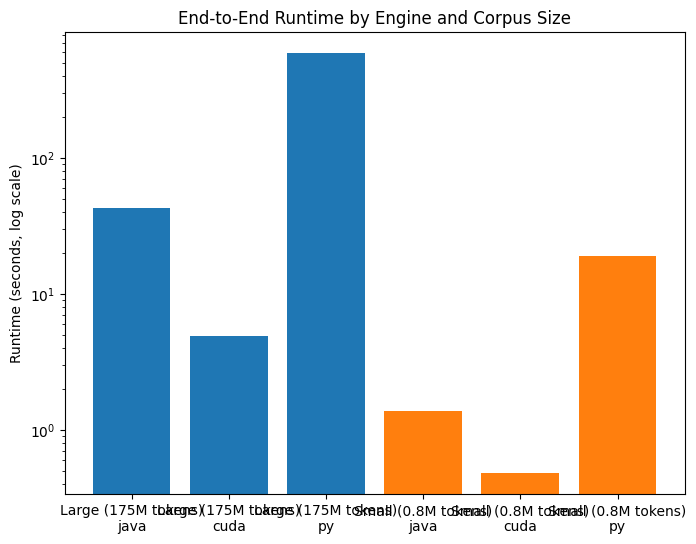

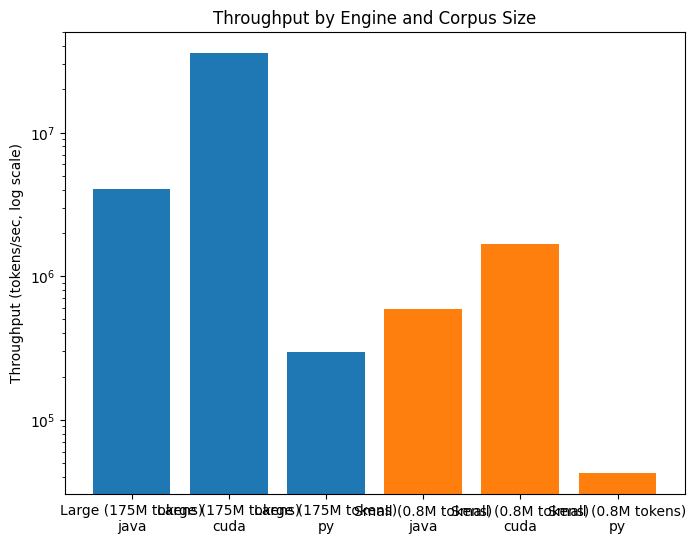

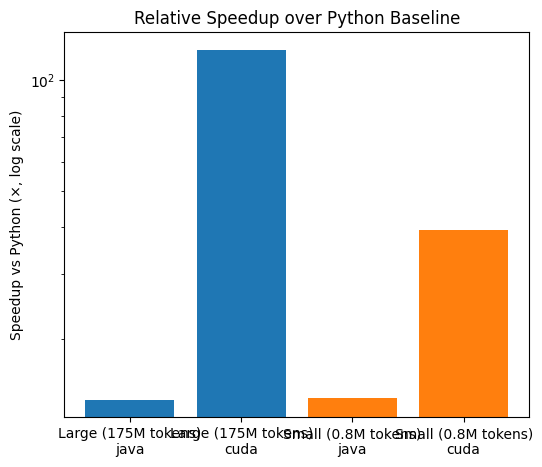

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV content into a DataFrame
data = """ts,engine,label,input_path,repeat,tokens,compute_mean_s,compute_ci95_s,compute_tokens_per_s,e2e_mean_s,e2e_ci95_s,e2e_tokens_per_s
2025-09-16T09:51:34.312222,java,large,data_parquet_big/,5,175583276,,,,43.2677,1.953,4058063.56
2025-09-16T09:52:22.799788,java,small,data_parquet/,5,807607,,,,1.3686,1.2722,590084.29
2025-09-16T10:00:56.707535,cuda,large,data_parquet_big/,5,175583276,,,,4.9088,1.3684,35769242.89
2025-09-16T10:03:09.497419,cuda,small,data_parquet/,5,807607,,,,0.4821,0.5734,1675326.79
2025-09-16T10:55:49.786682,py,large,data_parquet_big/,5,175583276,,,,592.9889,2.7654,296098.74
2025-09-16T10:05:25.617018,py,small,data_parquet/,5,807607,,,,18.9811,1.384,42548.03
"""

from io import StringIO
df = pd.read_csv(StringIO(data))

# Prepare labels
df["corpus"] = df["label"].map({"small": "Small (0.8M tokens)", "large": "Large (175M tokens)"})

# Runtime bar chart (log scale)
plt.figure(figsize=(8,6))
for corpus, group in df.groupby("corpus"):
    plt.bar([f"{corpus}\n{eng}" for eng in group["engine"]],
            group["e2e_mean_s"], label=corpus)
plt.yscale("log")
plt.ylabel("Runtime (seconds, log scale)")
plt.title("End-to-End Runtime by Engine and Corpus Size")
plt.show()

# Throughput bar chart (log scale)
plt.figure(figsize=(8,6))
for corpus, group in df.groupby("corpus"):
    plt.bar([f"{corpus}\n{eng}" for eng in group["engine"]],
            group["e2e_tokens_per_s"], label=corpus)
plt.yscale("log")
plt.ylabel("Throughput (tokens/sec, log scale)")
plt.title("Throughput by Engine and Corpus Size")
plt.show()

# Speedup relative to Python
speedups = []
for corpus, group in df.groupby("corpus"):
    py_time = group[group["engine"]=="py"]["e2e_mean_s"].values[0]
    for _, row in group.iterrows():
        if row["engine"] != "py":
            factor = py_time / row["e2e_mean_s"]
            speedups.append({"corpus": corpus, "engine": row["engine"], "speedup": factor})
speedups_df = pd.DataFrame(speedups)

plt.figure(figsize=(6,5))
for corpus, group in speedups_df.groupby("corpus"):
    plt.bar([f"{corpus}\n{eng}" for eng in group["engine"]],
            group["speedup"])
plt.yscale("log")
plt.ylabel("Speedup vs Python (×, log scale)")
plt.title("Relative Speedup over Python Baseline")
plt.show()
